# 📊 Campaign Viability Analyzer — Data Audit & Cleaning Notebook
### Kickstarter Dataset | Project 4: Predictive Sales Analytics Engine

---

**Author:** Aarsh Bhatnagar  
**Dataset:** Kickstarter Projects (ks-projects-201801.csv + ks-projects-201612.csv)  
**Goal:** Thoroughly audit both raw datasets, expose every data quality issue with visual proof, clean the data step-by-step, and produce a final pipeline-ready dataframe.

---

> **How to read this notebook:**  
> Every code cell is preceded by a markdown cell that explains:
> - **What** we are doing  
> - **Why** we are doing it  
> - **What to look for** in the output  

This notebook is the proof-of-work for all data decisions made before model building.


---
## Section 0 — Imports & Configuration

**What:** Load all required libraries and define every parameter in one place.  
**Why:** Centralizing configuration means you only change a value once — here — and it automatically updates everywhere in the notebook. No hunting through 50 cells to find where `test_size=0.2` was hardcoded.  
**Rule:** Never hardcode a number or path outside this cell.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# ── Visual style ──────────────────────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11
sns.set_theme(style='whitegrid', palette='muted')

# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    # File paths
    'path_2018' : '../raw_dataset/ks-projects-201801.csv',
    'path_2016' : '../raw_dataset/ks-projects-201612.csv',

    # Target
    'target_col'       : 'state',
    'valid_states'     : ['successful', 'failed'],
    'target_map'       : {'successful': 1, 'failed': 0},

    # Columns that CANNOT be used as features (post-campaign data)
    'leakage_cols'     : ['pledged', 'backers', 'usd pledged',
                          'usd_pledged_real', 'ID'],

    # Safe feature columns (known at launch time)
    'text_col'         : 'name',
    'numerical_cols' : ['usd_goal_real', 'campaign_duration_days', 'name_length', 'launch_month', 'launch_day_of_week', 'launch_year'],
    'categorical_cols' : ['category', 'main_category', 'currency', 'country'],

    # Date filters
    'min_launch_year'  : 2009,   # Kickstarter founded April 2009
    'min_duration_days': 1,
    'max_duration_days': 92,     # Kickstarter hard cap is 60 days; 92 allows edge cases

    # TF-IDF
    'tfidf_max_features': 2500,

    # Model
    'test_size'   : 0.20,
    'cv_folds'    : 5,
    'random_state': 42,
}

os.chdir(os.path.dirname(os.path.abspath('01_data_audit_and_cleaning.ipynb')))
os.makedirs('plots', exist_ok=True)
os.makedirs('data', exist_ok=True)

print("✅ Output directories ready.")
print("✅ Libraries loaded and CONFIG set.")
print(f"   Valid target states   : {CONFIG['valid_states']}")
print(f"   Leakage columns       : {CONFIG['leakage_cols']}")
print(f"   Min launch year       : {CONFIG['min_launch_year']}")
print(f"   Duration range (days) : {CONFIG['min_duration_days']} – {CONFIG['max_duration_days']}")


✅ Output directories ready.
✅ Libraries loaded and CONFIG set.
   Valid target states   : ['successful', 'failed']
   Leakage columns       : ['pledged', 'backers', 'usd pledged', 'usd_pledged_real', 'ID']
   Min launch year       : 2009
   Duration range (days) : 1 – 92


---
## Section 1 — Load Both Raw Datasets

**What:** Load `ks-projects-201801.csv` (2018) and `ks-projects-201612.csv` (2016) into separate DataFrames.  
**Why:** We have two versions of the same dataset. Before deciding which one to use, we must compare them on shape, columns, and data quality. We never assume a newer file is automatically better — we prove it.  
**What to look for:** Row counts, column names, and whether the 2016 file has any structural issues right out of the box.


In [2]:
# Load 2018 version
df_2018 = pd.read_csv(CONFIG['path_2018'], low_memory=False)

# Load 2016 version — requires latin-1 encoding (has special characters)
df_2016 = pd.read_csv(CONFIG['path_2016'], low_memory=False, encoding='latin-1')

# The 2016 file has trailing spaces in every column name — strip them
df_2016.columns = df_2016.columns.str.strip()

print("=" * 55)
print("  2018 DATASET")
print("=" * 55)
print(f"  Rows    : {df_2018.shape[0]:,}")
print(f"  Columns : {df_2018.shape[1]}")
print(f"  Cols    : {df_2018.columns.tolist()}")

print()
print("=" * 55)
print("  2016 DATASET")
print("=" * 55)
print(f"  Rows    : {df_2016.shape[0]:,}")
print(f"  Columns : {df_2016.shape[1]}")
print(f"  Cols    : {df_2016.columns.tolist()}")


  2018 DATASET
  Rows    : 378,661
  Columns : 15
  Cols    : ['ID', 'name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'pledged', 'state', 'backers', 'country', 'usd pledged', 'usd_pledged_real', 'usd_goal_real']

  2016 DATASET
  Rows    : 323,750
  Columns : 17
  Cols    : ['ID', 'name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'pledged', 'state', 'backers', 'country', 'usd pledged', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']


---
## Section 2 — Comparing Both Datasets

**What:** A systematic side-by-side audit of the two files across four dimensions: (1) column differences, (2) state column health, (3) ID overlap, and (4) USD conversion quality.  
**Why:** We need hard evidence to decide whether to combine them, use one, or discard one. Every decision must be data-driven — not assumed.  
**What to look for:** Any columns present in one file but not the other, and whether the 2016 `state` column contains valid values.


In [3]:
# ── 2.1: Column Differences ───────────────────────────────────────────────────
cols_2016 = set(df_2016.columns)
cols_2018 = set(df_2018.columns)

only_in_2016 = cols_2016 - cols_2018
only_in_2018 = cols_2018 - cols_2016
in_both      = cols_2016 & cols_2018

print("── Column Audit ──────────────────────────────────────────")
print(f"  Columns in BOTH       : {sorted(in_both)}")
print(f"  Only in 2016          : {sorted(only_in_2016)}")
print(f"  Only in 2018          : {sorted(only_in_2018)}")


── Column Audit ──────────────────────────────────────────
  Columns in BOTH       : ['ID', 'backers', 'category', 'country', 'currency', 'deadline', 'goal', 'launched', 'main_category', 'name', 'pledged', 'state', 'usd pledged']
  Only in 2016          : ['Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16']
  Only in 2018          : ['usd_goal_real', 'usd_pledged_real']


**Observation so far:**  
The 2016 dataset has 4 extra columns named `Unnamed: 13` through `Unnamed: 16`.  
The 2018 dataset has 2 additional columns: `usd_pledged_real` and `usd_goal_real` — corrected USD conversions.  
Let us inspect those unnamed columns next to understand what they actually contain.


In [4]:
# ── 2.2: Inspect the 4 unnamed columns in 2016 ──────────────────────────────
unnamed_cols = [c for c in df_2016.columns if 'Unnamed' in c]

print("── Unnamed Column Audit (2016 only) ─────────────────────")
for col in unnamed_cols:
    null_pct = df_2016[col].isnull().mean() * 100
    sample   = df_2016[col].dropna().head(5).tolist()
    print(f"  {col}")
    print(f"    Null rate : {null_pct:.1f}%")
    print(f"    Sample    : {sample}")
    print()


── Unnamed Column Audit (2016 only) ─────────────────────
  Unnamed: 13
    Null rate : 99.8%
    Sample    : ['504.94765278', '3984', '525', '0', '3035']

  Unnamed: 14
    Null rate : 100.0%
    Sample    : ['20', '0', '26', 'US', '1']

  Unnamed: 15
    Null rate : 100.0%
    Sample    : ['9854', '0', '0', 'US']

  Unnamed: 16
    Null rate : 100.0%
    Sample    : [25.0]



**Finding:** All 4 unnamed columns are over 99% null — they are leftover CSV formatting artifacts with no usable content. They will be discarded.  

Now let us check the most critical column — `state` — in the 2016 file.  
**Why this matters:** `state` is the source of our prediction target. If it is corrupted, the entire 2016 dataset becomes unusable.


In [5]:
# ── 2.3: State Column Health Check ───────────────────────────────────────────
valid_states = ['failed', 'successful', 'canceled', 'live', 'undefined', 'suspended']

state_2018 = df_2018['state'].value_counts()
state_2016 = df_2016['state'].value_counts()

bad_state_rows_2016 = df_2016[~df_2016['state'].isin(valid_states)]
bad_state_count     = len(bad_state_rows_2016)

print("── 2018 State Distribution (clean baseline) ──────────────")
print(state_2018.to_string())

print()
print("── 2016 State Distribution (all unique values) ───────────")
print(f"  Total unique values in 2016 state column: {df_2016['state'].nunique()}")
print(f"  Rows with NON-STANDARD state values: {bad_state_count:,}")
print()
print("  Sample of invalid state values found in 2016:")
print(bad_state_rows_2016['state'].value_counts().head(15).to_string())


── 2018 State Distribution (clean baseline) ──────────────
state
failed        197719
successful    133956
canceled       38779
undefined       3562
live            2799
suspended       1846

── 2016 State Distribution (all unique values) ───────────
  Total unique values in 2016 state column: 410
  Rows with NON-STANDARD state values: 632

  Sample of invalid state values found in 2016:
state
0      96
1      15
5      11
25     11
10     10
100     8
50      7
65      6
20      5
35      5
2       5
55      5
110     5
21      4
30      4


**Critical Finding 🚨:**  
The 2016 `state` column contains numeric values like `0`, `1`, `5`, `25`, `100` in 632 rows.  
These are not valid campaign states — they are data corruption (possibly percentage values pasted into the wrong column).  
This alone makes the 2016 dataset unreliable as a source for our target variable.

Let us now check whether the 2016 dataset adds any unique campaigns not already in 2018.


In [6]:
# ── 2.4: ID Overlap — Does 2016 add new campaigns? ───────────────────────────
df_2016['ID'] = df_2016['ID'].astype(str).str.strip()
df_2018['ID'] = df_2018['ID'].astype(str).str.strip()

ids_2016 = set(df_2016['ID'])
ids_2018 = set(df_2018['ID'])

only_in_2016_ids = ids_2016 - ids_2018
overlap_ids      = ids_2016 & ids_2018

print("── Campaign ID Overlap ────────────────────────────────────")
print(f"  Total campaigns in 2016  : {len(ids_2016):,}")
print(f"  Total campaigns in 2018  : {len(ids_2018):,}")
print(f"  Shared IDs (overlap)     : {len(overlap_ids):,}")
print(f"  IDs ONLY in 2016         : {len(only_in_2016_ids):,}")
print()
if len(only_in_2016_ids) == 0:
    print("  ✅ VERDICT: Every campaign in the 2016 dataset already exists in 2018.")
    print("     Combining the files adds ZERO new rows of data.")
else:
    print(f"  ⚠️  {len(only_in_2016_ids):,} campaigns exist only in 2016.")


── Campaign ID Overlap ────────────────────────────────────
  Total campaigns in 2016  : 323,750
  Total campaigns in 2018  : 378,661
  Shared IDs (overlap)     : 323,750
  IDs ONLY in 2016         : 0

  ✅ VERDICT: Every campaign in the 2016 dataset already exists in 2018.
     Combining the files adds ZERO new rows of data.


**Final Verdict on Dataset Combination:**

| Check | 2016 File | 2018 File |
|---|---|---|
| Row count | 323,750 | 378,661 |
| Column names | Trailing spaces on all names | Clean |
| Extra columns | 4 unnamed garbage columns | None |
| `state` corruption | 632 rows with numeric values | Zero corruption |
| USD conversion | Old method only (`usd pledged`) | Corrected (`usd_goal_real`, `usd_pledged_real`) |
| Unique campaigns not in 2018 | **0** | — |

**Decision: Use only `ks-projects-201801.csv` (2018).** The 2016 file adds no new campaigns, introduces corrupt state values, and has inferior USD conversion columns. Combining would only add noise.

All further work proceeds with `df_2018` only.


---
## Section 3 — Raw Data Audit (2018 Dataset)

**What:** A full inspection of the 2018 dataset as-is, before any cleaning. We check shape, dtypes, nulls, and every column's content.  
**Why:** You must understand what you are working with before touching anything. Cleaning without auditing is guessing.  
**What to look for:** Missing values, wrong data types (dates stored as strings), and columns that look fine but contain trap values.


In [7]:
# Work on the 2018 dataset from here onward
df = df_2018.copy()

print("── Raw Shape ─────────────────────────────────────────────")
print(f"  Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")

print()
print("── Data Types ────────────────────────────────────────────")
print(df.dtypes.to_string())

print()
print("── Null Count per Column ─────────────────────────────────")
nulls = df.isnull().sum()
for col, n in nulls.items():
    flag = ' ⚠️' if n > 0 else ' ✅'
    print(f"  {col:<22} {n:>6,} nulls{flag}")


── Raw Shape ─────────────────────────────────────────────
  Rows: 378,661   Columns: 15

── Data Types ────────────────────────────────────────────
ID                   object
name                 object
category             object
main_category        object
currency             object
deadline             object
goal                float64
launched             object
pledged             float64
state                object
backers               int64
country              object
usd pledged         float64
usd_pledged_real    float64
usd_goal_real       float64

── Null Count per Column ─────────────────────────────────
  ID                          0 nulls ✅
  name                        4 nulls ⚠️
  category                    0 nulls ✅
  main_category               0 nulls ✅
  currency                    0 nulls ✅
  deadline                    0 nulls ✅
  goal                        0 nulls ✅
  launched                    0 nulls ✅
  pledged                     0 nulls ✅
  state   

In [ ]:
# ── First 5 rows — visual sanity check ───────────────────────────────────────
print("── First 5 Rows ──────────────────────────────────────────")
df.head()

── First 5 Rows ──────────────────────────────────────────


(378661, 15)

---
## Section 4 — Data Leakage Audit 🚨 (Most Important Section)

**What:** Identify and remove columns that contain information that would NOT be available at the time of prediction.  
**Why:** This is the most common and most damaging mistake in this dataset.

Imagine you are building a tool that a creator uses **before** they launch a campaign to check if it will succeed.  
At that moment, the creator has not yet launched — so they have zero pledges, zero backers, and zero funding received.  
If we train our model using `pledged` or `backers`, the model learns the answer, not the pattern.  
A model trained with leakage will appear to have 99% accuracy but will fail completely on real unseen campaigns.

**What to look for:** The table below confirms which columns are safe to use vs which must be removed.


In [11]:
# ── Leakage Column Analysis ──────────────────────────────────────────────────
leakage_info = {
    'pledged'         : 'Total money raised — only known AFTER campaign ends',
    'backers'         : 'Number of supporters — only known AFTER campaign ends',
    'usd pledged'     : 'Old USD conversion of pledged — same leak, different unit',
    'usd_pledged_real': 'Corrected USD conversion of pledged — still a leak',
    'ID'              : 'Random identifier — zero predictive signal',
}

safe_info = {
    'name'            : '✅ Campaign title — known at launch',
    'category'        : '✅ Campaign category — known at launch',
    'main_category'   : '✅ Broad category — known at launch',
    'currency'        : '✅ Currency used — known at launch',
    'goal'            : '✅ Funding goal set by creator — known at launch',
    'usd_goal_real'   : '✅ Goal in USD — derived from goal+currency, known at launch',
    'launched'        : '✅ Launch date — known at launch (it IS the launch)',
    'deadline'        : '✅ End date — set at launch by creator',
    'country'         : '✅ Creator country — known at launch',
}

print("── 🚨 LEAKAGE COLUMNS (must be removed) ─────────────────")
for col, reason in leakage_info.items():
    present = '✅ Present' if col in df.columns else '❌ Not found'
    print(f"  [{present}]  {col:<22} — {reason}")

print()
print("── ✅ SAFE FEATURE COLUMNS ───────────────────────────────")
for col, reason in safe_info.items():
    print(f"  {reason:<45} ({col})")

# Show what percentage of rows have non-null leakage data
print()
print("── Leakage Column Non-Null Rates ─────────────────────────")
for col in leakage_info:
    if col in df.columns:
        non_null = df[col].notnull().mean() * 100
        print(f"  {col:<22}  {non_null:.1f}% non-null  ← this data exists and will corrupt your model")


── 🚨 LEAKAGE COLUMNS (must be removed) ─────────────────
  [✅ Present]  pledged                — Total money raised — only known AFTER campaign ends
  [✅ Present]  backers                — Number of supporters — only known AFTER campaign ends
  [✅ Present]  usd pledged            — Old USD conversion of pledged — same leak, different unit
  [✅ Present]  usd_pledged_real       — Corrected USD conversion of pledged — still a leak
  [✅ Present]  ID                     — Random identifier — zero predictive signal

── ✅ SAFE FEATURE COLUMNS ───────────────────────────────
  ✅ Campaign title — known at launch            (name)
  ✅ Campaign category — known at launch         (category)
  ✅ Broad category — known at launch            (main_category)
  ✅ Currency used — known at launch             (currency)
  ✅ Funding goal set by creator — known at launch (goal)
  ✅ Goal in USD — derived from goal+currency, known at launch (usd_goal_real)
  ✅ Launch date — known at launch (it IS the launch) (

In [12]:
# ── Drop leakage columns ─────────────────────────────────────────────────────
cols_before = df.shape[1]
df.drop(columns=CONFIG['leakage_cols'], inplace=True)
cols_after  = df.shape[1]

print(f"  Columns before leakage drop : {cols_before}")
print(f"  Columns after leakage drop  : {cols_after}")
print(f"  Columns removed             : {cols_before - cols_after}")
print(f"  Remaining columns           : {df.columns.tolist()}")


  Columns before leakage drop : 15
  Columns after leakage drop  : 10
  Columns removed             : 5
  Remaining columns           : ['name', 'category', 'main_category', 'currency', 'deadline', 'goal', 'launched', 'state', 'country', 'usd_goal_real']


---
## Section 5 — Target Variable: The `state` Column

**What:** Inspect the distribution of the `state` column and convert it to a binary target (1 = successful, 0 = failed).  
**Why:** Our model is a binary classifier — it predicts one of two outcomes. The `state` column currently has 6 values.  
- `successful` → **1** (the outcome we want to predict)
- `failed` → **0** (the other outcome)
- `canceled`, `live`, `undefined`, `suspended` → **drop these rows**

Canceled campaigns are ambiguous — the creator chose to stop, not that the market rejected them. Including them as "failed" would mislabel data. We drop them to keep our target clean and unambiguous.

**What to look for:** The class balance after filtering. If 95%+ rows are one class, we have an imbalance problem requiring special handling.


In [16]:
df['state'].value_counts()

state
failed        197719
successful    133956
Name: count, dtype: int64

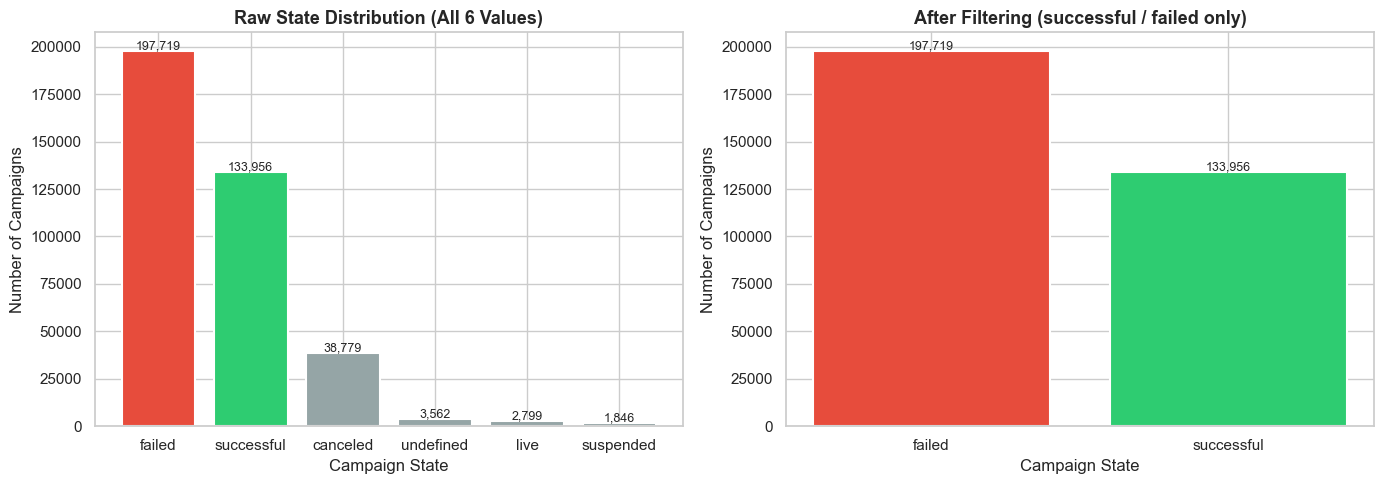

  Rows dropped (non successful/failed) : 46,986
  Rows kept                            : 331,675


In [14]:
# ── Plot raw state distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw counts
state_counts = df['state'].value_counts()
colors = ['#2ecc71' if s == 'successful' else
          '#e74c3c' if s == 'failed' else '#95a5a6'
          for s in state_counts.index]
axes[0].bar(state_counts.index, state_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Raw State Distribution (All 6 Values)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Campaign State')
axes[0].set_ylabel('Number of Campaigns')
for i, (s, v) in enumerate(zip(state_counts.index, state_counts.values)):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

# Right: after filter
keep_mask    = df['state'].isin(CONFIG['valid_states'])
state_after  = df[keep_mask]['state'].value_counts()
axes[1].bar(state_after.index, state_after.values,
            color=['#e74c3c', '#2ecc71'], edgecolor='white', linewidth=1.5)
axes[1].set_title('After Filtering (successful / failed only)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Campaign State')
axes[1].set_ylabel('Number of Campaigns')
for i, (s, v) in enumerate(zip(state_after.index, state_after.values)):
    axes[1].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/01_state_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

rows_dropped = (~keep_mask).sum()
print(f"  Rows dropped (non successful/failed) : {rows_dropped:,}")
print(f"  Rows kept                            : {keep_mask.sum():,}")


## cancelled , undefined  live suspended have been remove from data ste  so data losses approx 37 thousand rows 

In [15]:
# ── Apply state filter and create binary target ───────────────────────────────
df = df[df[CONFIG['target_col']].isin(CONFIG['valid_states'])].copy()
df['target'] = df[CONFIG['target_col']].map(CONFIG['target_map'])

success_rate = df['target'].mean()
print(f"  Final dataset shape : {df.shape}")
print(f"  Success rate        : {success_rate:.2%}")
print(f"  Failure rate        : {1-success_rate:.2%}")
print()
if success_rate < 0.10 or success_rate > 0.90:
    print("  ⚠️  Class imbalance detected. Will use class_weight='balanced' in model.")
else:
    print("  ✅ Class balance is acceptable for standard training.")


  Final dataset shape : (331675, 11)
  Success rate        : 40.39%
  Failure rate        : 59.61%

  ✅ Class balance is acceptable for standard training.


---
## Section 6 — Date Column Audit

**What:** Parse `launched` and `deadline` from strings to proper datetime objects, then check for corrupted date values.  
**Why:** Dates stored as strings cannot be used for math operations. We need them as datetime objects to calculate `campaign_duration_days`.  
The dataset is known to contain a `1970-01-01` launch date — a Unix epoch artifact. Unix timestamps count seconds from January 1, 1970. A failed timestamp conversion produces this date.  
Kickstarter was founded in **April 2009** — any campaign with a launch date before 2009 is provably corrupt.

**What to look for:** Rows with launch year < 2009 (impossible), and campaign durations that exceed 92 days (Kickstarter's maximum is 60 days — we allow slight buffer for edge cases).


In [ ]:
# ── Parse dates ─────────────────────────────────────────────────────────────
df['launched'] = pd.to_datetime(df['launched'], errors='coerce')
df['deadline'] = pd.to_datetime(df['deadline'], errors='coerce')

print("── Date Range (before filtering) ─────────────────────────")
print(f"  Launched : {df['launched'].min()}  →  {df['launched'].max()}")
print(f"  Deadline : {df['deadline'].min()}  →  {df['deadline'].max()}")

print()
corrupt_dates = df[df['launched'].dt.year < CONFIG['min_launch_year']]
print(f"  ⚠️  Rows with launch year < {CONFIG['min_launch_year']} (corrupt): {len(corrupt_dates):,}")
print()
print("  Sample corrupt rows:")
print(corrupt_dates[['name', 'launched', 'deadline', 'state']].head(5).to_string())


── Date Range (before filtering) ─────────────────────────
  Launched : 2009-04-21 21:02:48  →  2017-12-29 03:22:32
  Deadline : 2009-05-03 00:00:00  →  2018-01-02 00:00:00

  ⚠️  Rows with launch year < 2009 (corrupt): 0

  Sample corrupt rows:
Empty DataFrame
Columns: [name, launched, deadline, state]
Index: []


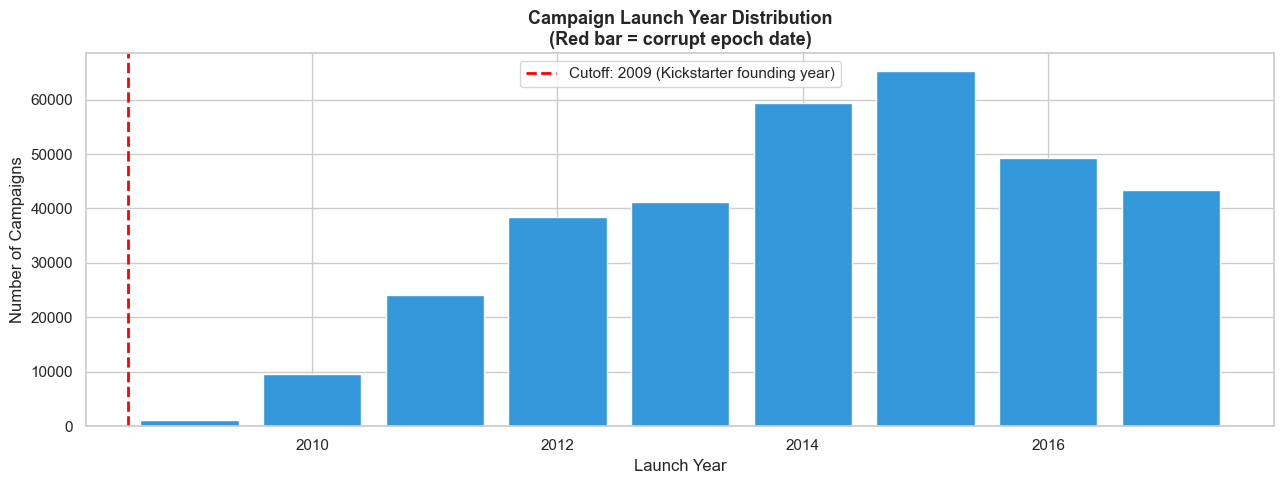

In [ ]:
# ── Plot launch year distribution ────────────────────────────────────────────
os.makedirs('plots', exist_ok=True)

launch_years = df['launched'].dt.year.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(launch_years.index, launch_years.values,
       color=['#e74c3c' if y < CONFIG['min_launch_year'] else '#3498db'
              for y in launch_years.index],
       edgecolor='white')
ax.axvline(x=CONFIG['min_launch_year'] - 0.5, color='red', linestyle='--', linewidth=2,
           label=f'Cutoff: {CONFIG["min_launch_year"]} (Kickstarter founding year)')
ax.set_title('Campaign Launch Year Distribution\n(Red bar = corrupt epoch date)', fontsize=13, fontweight='bold')
ax.set_xlabel('Launch Year')
ax.set_ylabel('Number of Campaigns')
ax.legend()
plt.tight_layout()
plt.savefig('plots/02_launch_year_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Remove corrupt dates ──────────────────────────────────────────────────────
rows_before = len(df)
df = df[df['launched'].dt.year >= CONFIG['min_launch_year']].copy()
rows_after  = len(df)

print(f"  Rows removed (corrupt dates) : {rows_before - rows_after:,}")
print(f"  Rows remaining               : {rows_after:,}")


  Rows removed (corrupt dates) : 0
  Rows remaining               : 331,675


---
## Section 7 — Engineering `campaign_duration_days`

**What:** Calculate the number of days each campaign ran (from `launched` to `deadline`) and filter out impossible durations.  
**Why:** Campaign duration is a real business signal. A creator who runs a 5-day campaign is behaving very differently from one who runs a 60-day campaign. We engineer this as a feature.  
However, raw duration has extreme outliers — durations of 16,000+ days exist in the data (roughly 45 years). These are clearly data entry errors.  
Kickstarter's official maximum campaign length is **60 days**. We set our filter ceiling at **92 days** to account for any platform edge cases or API rounding artifacts.

**What to look for:** The duration distribution plot showing the outliers, and how many rows get removed.


In [ ]:
# ── Calculate duration ───────────────────────────────────────────────────────
df['campaign_duration_days'] = (df['deadline'] - df['launched']).dt.days

print("── Duration Stats (before filtering) ────────────────────")
print(df['campaign_duration_days'].describe().round(1).to_string())

# Show extreme outliers
print()
print("── Rows with duration > 92 days (sample) ────────────────")
outliers = df[df['campaign_duration_days'] > CONFIG['max_duration_days']]
print(f"  Total outlier rows: {len(outliers):,}")
print(outliers[['name', 'launched', 'deadline', 'campaign_duration_days']].head(8).to_string())


── Duration Stats (before filtering) ────────────────────
count    331675.0
mean         33.0
std          12.7
min           0.0
25%          29.0
50%          29.0
75%          35.0
max          91.0

── Rows with duration > 92 days (sample) ────────────────
  Total outlier rows: 0
Empty DataFrame
Columns: [name, launched, deadline, campaign_duration_days]
Index: []


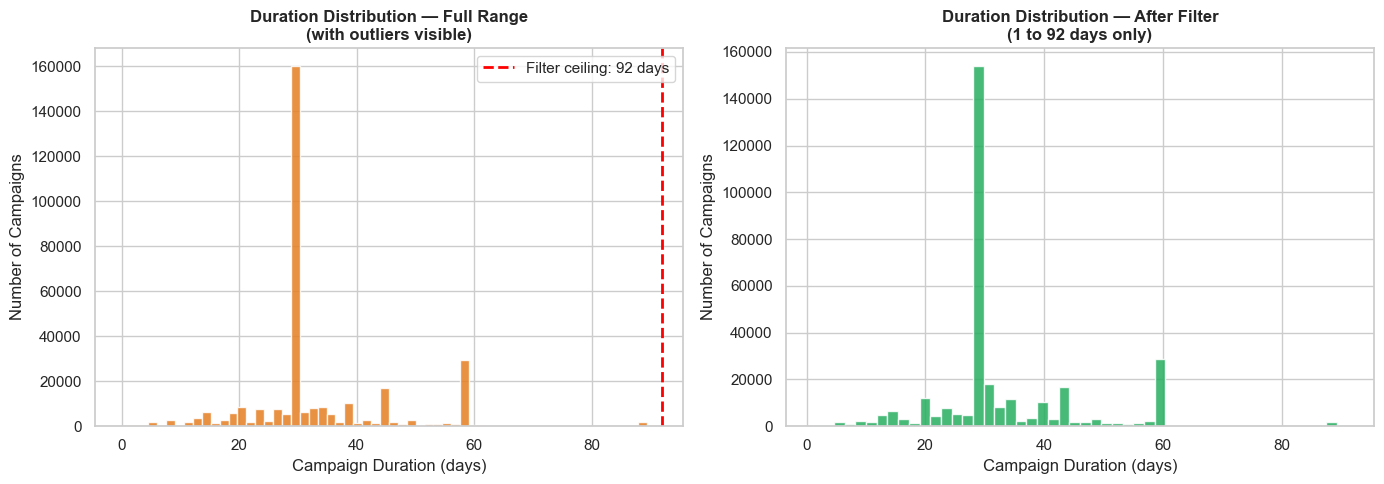

In [ ]:
# ── Plot duration distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full range showing outliers
axes[0].hist(df['campaign_duration_days'].clip(upper=200), bins=60,
             color='#e67e22', edgecolor='white', alpha=0.85)
axes[0].axvline(CONFIG['max_duration_days'], color='red', linestyle='--', linewidth=2,
                label=f'Filter ceiling: {CONFIG["max_duration_days"]} days')
axes[0].set_title('Duration Distribution — Full Range\n(with outliers visible)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Campaign Duration (days)')
axes[0].set_ylabel('Number of Campaigns')
axes[0].legend()

# Right: after filter
clean_duration = df[df['campaign_duration_days'].between(
    CONFIG['min_duration_days'], CONFIG['max_duration_days'])]['campaign_duration_days']
axes[1].hist(clean_duration, bins=50, color='#27ae60', edgecolor='white', alpha=0.85)
axes[1].set_title('Duration Distribution — After Filter\n(1 to 92 days only)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Campaign Duration (days)')
axes[1].set_ylabel('Number of Campaigns')

plt.tight_layout()
plt.savefig('plots/03_duration_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Apply duration filter ────────────────────────────────────────────────────
rows_before = len(df)
df = df[df['campaign_duration_days'].between(
    CONFIG['min_duration_days'],
    CONFIG['max_duration_days']
)].copy()
rows_after = len(df)

print(f"  Rows removed (duration outliers) : {rows_before - rows_after:,}")
print(f"  Rows remaining                   : {rows_after:,}")
print()
print("── Duration Stats (after filtering) ─────────────────────")
print(df['campaign_duration_days'].describe().round(1).to_string())


  Rows removed (duration outliers) : 92
  Rows remaining                   : 331,583

── Duration Stats (after filtering) ─────────────────────
count    331583.0
mean         33.0
std          12.7
min           1.0
25%          29.0
50%          29.0
75%          35.0
max          91.0


---
## Section 8 — Text Feature Audit: `name` Column

**What:** Inspect the campaign title (`name`) for nulls, length distribution, and basic quality issues.  
**Why:** The `name` column is our only text feature — it will be converted into a TF-IDF matrix later. Null names cannot be vectorized and must be handled. Very short names (1–2 characters) are likely placeholder entries. Understanding the length distribution tells us whether `name_length` is a useful feature.

**What to look for:** Null count, length distribution, and suspiciously short or long titles.


In [ ]:
# ── Null check ──────────────────────────────────────────────────────────────
null_names = df['name'].isnull().sum()
print(f"  Null names found: {null_names}")

# Fill nulls with empty string (TF-IDF handles empty strings gracefully)
df['name'] = df['name'].fillna('')

# Engineer name_length feature
df['name_length'] = df['name'].str.len()

print()
print("── Name Length Stats ─────────────────────────────────────")
print(df['name_length'].describe().round(1).to_string())

print()
print("── Very Short Names (< 5 characters) ────────────────────")
short_names = df[df['name_length'] < 5][['name', 'name_length', 'target']].head(10)
print(short_names.to_string())


  Null names found: 3

── Name Length Stats ─────────────────────────────────────
count    331583.0
mean         34.2
std          16.0
min           0.0
25%          21.0
50%          33.0
75%          48.0
max          85.0

── Very Short Names (< 5 characters) ────────────────────
      name  name_length  target
196   Ropw            4       0
220   High            4       0
299    Lei            3       1
716    ONE            3       0
1577  Nelo            4       1
1840  iRoo            4       0
1871  Tiem            4       0
3257    HI            2       0
4198  Finn            4       0
4323   XXX            3       0


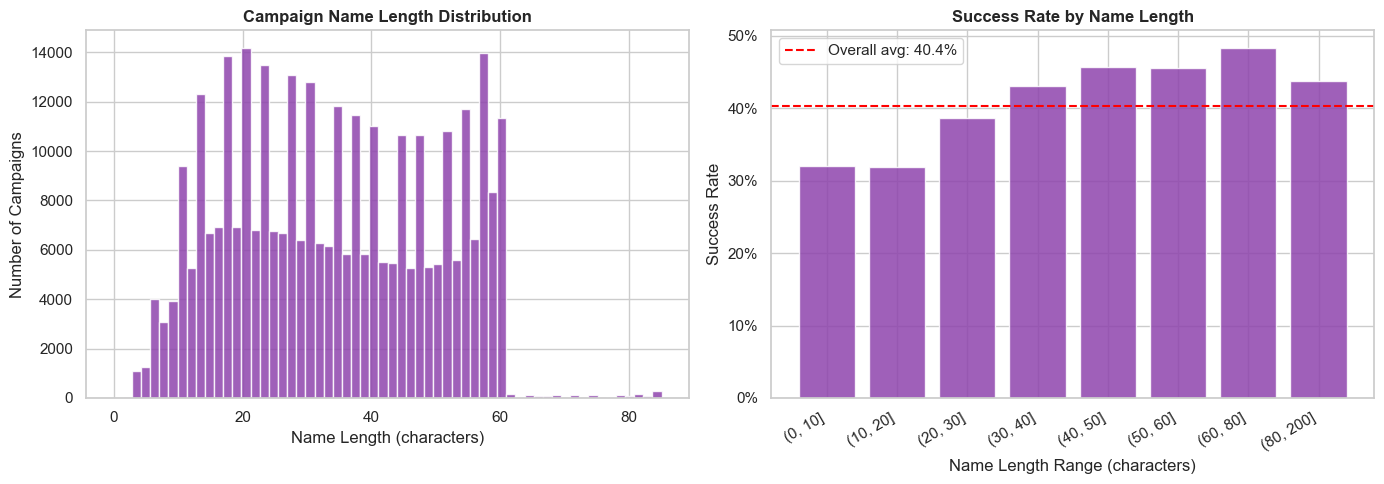

In [ ]:
# ── Plot name length distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['name_length'].clip(upper=100), bins=60,
             color='#8e44ad', edgecolor='white', alpha=0.85)
axes[0].set_title('Campaign Name Length Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Name Length (characters)')
axes[0].set_ylabel('Number of Campaigns')

# Name length vs success rate
bins     = [0, 10, 20, 30, 40, 50, 60, 80, 200]
df['name_bin'] = pd.cut(df['name_length'], bins=bins)
success_by_len = df.groupby('name_bin', observed=True)['target'].mean()

axes[1].bar(range(len(success_by_len)), success_by_len.values,
            color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(len(success_by_len)))
axes[1].set_xticklabels([str(b) for b in success_by_len.index], rotation=30, ha='right')
axes[1].set_title('Success Rate by Name Length', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Name Length Range (characters)')
axes[1].set_ylabel('Success Rate')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1].axhline(df['target'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Overall avg: {df["target"].mean():.1%}')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/04_name_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['name_bin'], inplace=True)


---
## Section 9 — Numerical Feature Audit: `usd_goal_real` and `campaign_duration_days`

**What:** Inspect the distribution and outliers in our two primary numerical features.  
**Why:** Tree models and logistic regression both benefit from understanding the scale and skew of numerical inputs. Extreme outliers in funding goals (e.g., a $100M goal on a crowdfunding platform) are likely test entries or jokes — they skew the StandardScaler and damage model performance.  

`usd_goal_real` is the preferred goal column because it normalizes all currencies to USD using accurate historical exchange rates — unlike the raw `goal` column which mixes GBP, EUR, USD, etc.

**What to look for:** Right-skewed distributions with extreme outliers, and whether those outliers follow a realistic business pattern.


In [ ]:
# ── Goal distribution ────────────────────────────────────────────────────────
print("── usd_goal_real Stats ───────────────────────────────────")
print(df['usd_goal_real'].describe().apply(lambda x: f'{x:,.2f}').to_string())

print()
print("── Extreme Outliers (goal > $1M) ────────────────────────")
high_goal = df[df['usd_goal_real'] > 1_000_000]
print(f"  Rows with goal > $1M : {len(high_goal):,}")
print(high_goal[['name', 'usd_goal_real', 'currency', 'state']].head(10).to_string())


── usd_goal_real Stats ───────────────────────────────────
count        331,583.00
mean          41,186.57
std        1,095,277.17
min                0.01
25%            2,000.00
50%            5,000.00
75%           15,000.00
max      166,361,390.71

── Extreme Outliers (goal > $1M) ────────────────────────
  Rows with goal > $1M : 838
                                                       name  usd_goal_real currency   state
340                                          You in a novel     1076403.09      EUR  failed
971                              Maori MBT Awareness Centre     1600768.37      CAD  failed
1042                                 The Old Soul of a Lion     3000000.00      USD  failed
1144                                The Million Pound Shirt     1505185.36      GBP  failed
1795                                          ** GOLIATH **     3575408.62      CAD  failed
2920                                           Thermal Safe     2000000.00      USD  failed
2993             

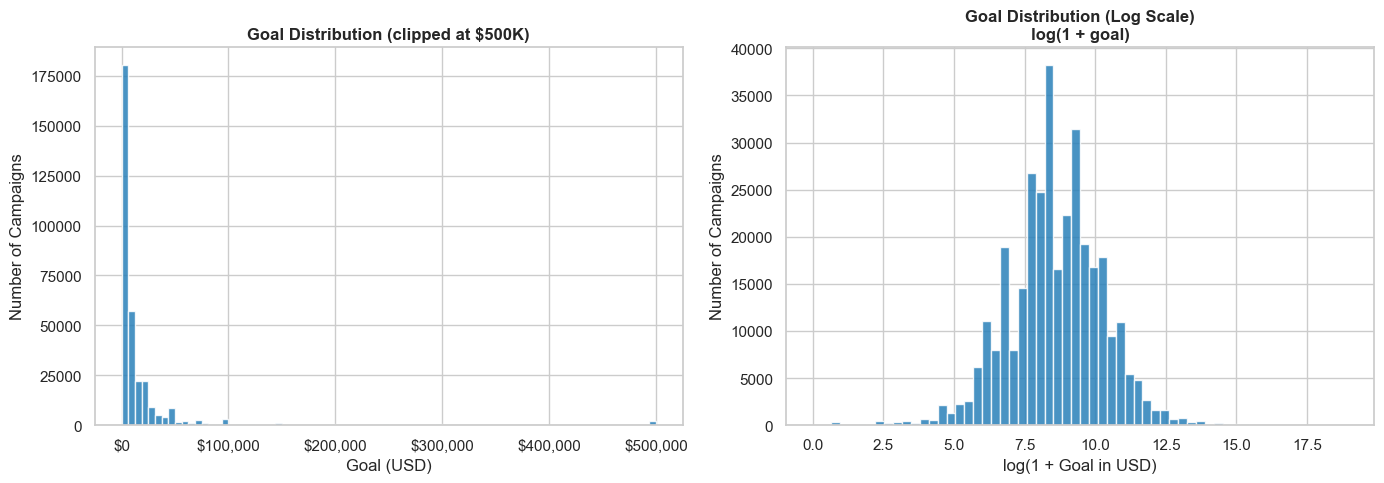

In [ ]:
# ── Plot goal distribution (log scale) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: raw distribution (clipped for visibility)
axes[0].hist(df['usd_goal_real'].clip(upper=500_000), bins=80,
             color='#2980b9', edgecolor='white', alpha=0.85)
axes[0].set_title('Goal Distribution (clipped at $500K)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Goal (USD)')
axes[0].set_ylabel('Number of Campaigns')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Right: log scale (shows full range properly)
log_goals = np.log1p(df['usd_goal_real'])
axes[1].hist(log_goals, bins=60, color='#2980b9', edgecolor='white', alpha=0.85)
axes[1].set_title('Goal Distribution (Log Scale)\nlog(1 + goal)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('log(1 + Goal in USD)')
axes[1].set_ylabel('Number of Campaigns')

plt.tight_layout()
plt.savefig('plots/05_goal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


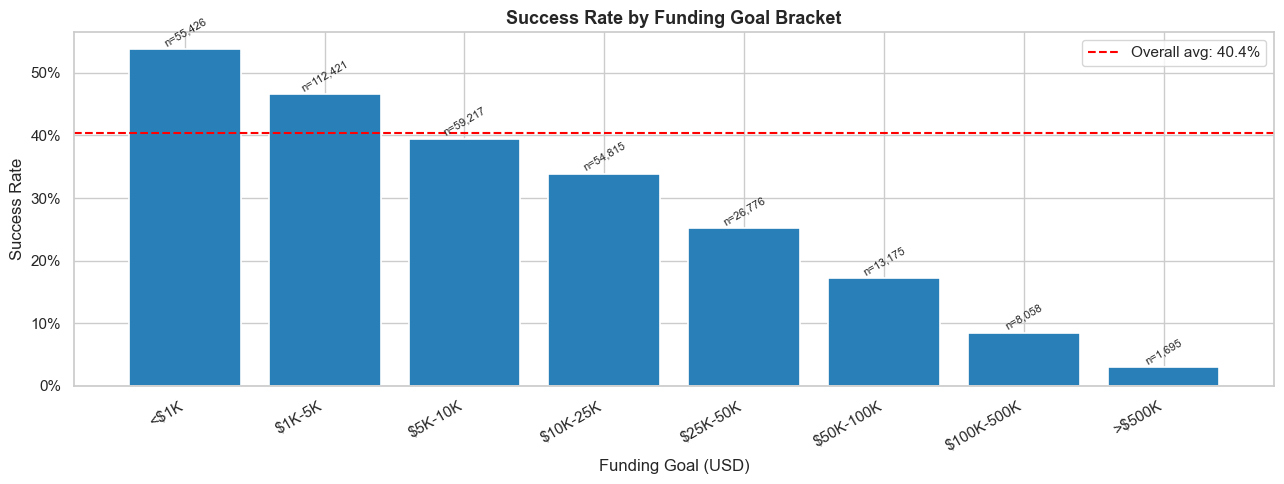

In [ ]:
# ── Success rate by goal bracket ─────────────────────────────────────────────
bins   = [0, 1000, 5000, 10000, 25000, 50000, 100000, 500000, float('inf')]
labels = ['<$1K', '$1K-5K', '$5K-10K', '$10K-25K',
          '$25K-50K', '$50K-100K', '$100K-500K', '>$500K']

df['goal_bin'] = pd.cut(df['usd_goal_real'], bins=bins, labels=labels)
success_by_goal = df.groupby('goal_bin', observed=True)['target'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(range(len(success_by_goal)), success_by_goal['mean'].values,
              color='#2980b9', edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.set_title('Success Rate by Funding Goal Bracket', fontsize=13, fontweight='bold')
ax.set_xlabel('Funding Goal (USD)')
ax.set_ylabel('Success Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(df['target'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {df["target"].mean():.1%}')
ax.legend()

# Add campaign count labels on bars
for i, (rate, count) in enumerate(zip(success_by_goal['mean'], success_by_goal['count'])):
    ax.text(i, rate + 0.005, f'n={count:,}', ha='center', fontsize=8, rotation=30)

plt.tight_layout()
plt.savefig('plots/06_success_by_goal.png', dpi=150, bbox_inches='tight')
plt.show()

df.drop(columns=['goal_bin'], inplace=True)


---
## Section 10 — Categorical Feature Audit

**What:** Inspect the four categorical columns: `category`, `main_category`, `currency`, and `country`.  
**Why:** Categorical columns contain non-numeric text labels. Before encoding them, we need to understand:
1. How many unique values each column has (cardinality)
2. Whether any values are rare (< 0.1% of data) — rare categories can cause issues in OneHotEncoder
3. Whether the category a campaign belongs to predicts success differently

**What to look for:** High-cardinality columns (many unique values), rare categories, and strong success-rate differences between categories.


In [ ]:
# ── Cardinality and null check ───────────────────────────────────────────────
cat_cols = CONFIG['categorical_cols']

print("── Categorical Column Summary ────────────────────────────")
for col in cat_cols:
    n_unique = df[col].nunique()
    n_null   = df[col].isnull().sum()
    print(f"  {col:<20} {n_unique:>4} unique values   {n_null:>5} nulls")


── Categorical Column Summary ────────────────────────────
  category              159 unique values       0 nulls
  main_category          15 unique values       0 nulls
  currency               14 unique values       0 nulls
  country                23 unique values       0 nulls


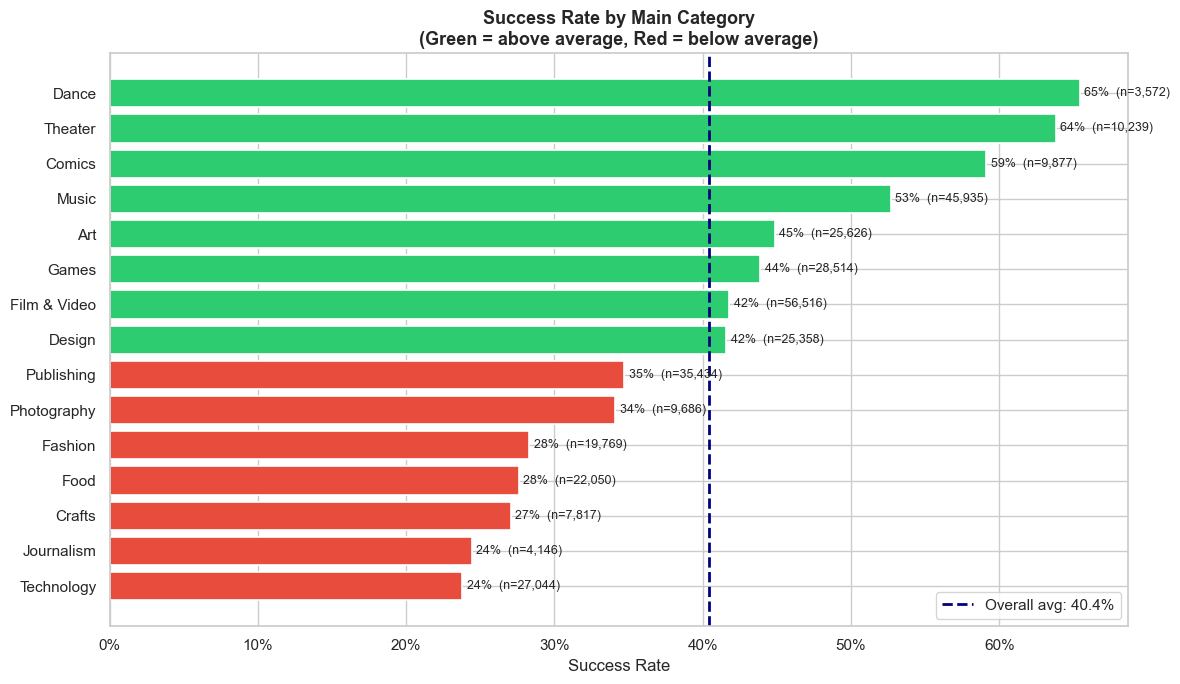

In [ ]:
# ── Success rate by main_category ────────────────────────────────────────────
main_cat_stats = (df.groupby('main_category')['target']
                    .agg(['mean', 'count'])
                    .rename(columns={'mean': 'success_rate', 'count': 'campaigns'})
                    .sort_values('success_rate', ascending=True))

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if r > df['target'].mean() else '#e74c3c'
          for r in main_cat_stats['success_rate']]
ax.barh(main_cat_stats.index, main_cat_stats['success_rate'],
        color=colors, edgecolor='white', linewidth=1.2)
ax.axvline(df['target'].mean(), color='navy', linestyle='--', linewidth=2,
           label=f'Overall avg: {df["target"].mean():.1%}')
ax.set_title('Success Rate by Main Category\n(Green = above average, Red = below average)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Success Rate')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()

for i, (rate, count) in enumerate(zip(main_cat_stats['success_rate'],
                                       main_cat_stats['campaigns'])):
    ax.text(rate + 0.003, i, f'{rate:.0%}  (n={count:,})', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/07_success_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ── Country distribution ─────────────────────────────────────────────────────
country_counts = df['country'].value_counts()
print("── Top 15 Countries ──────────────────────────────────────")
print(country_counts.head(15).to_string())

print()
rare_countries = country_counts[country_counts < 50]
print(f"  Countries with fewer than 50 campaigns: {len(rare_countries)}")
print(f"  {rare_countries.index.tolist()}")


── Top 15 Countries ──────────────────────────────────────
country
US    261294
GB     29439
CA     12366
AU      6613
DE      3436
FR      2520
NL      2411
IT      2369
ES      1872
SE      1509
MX      1410
NZ      1274
DK       926
IE       683
CH       652

  Countries with fewer than 50 campaigns: 1
  ['JP']


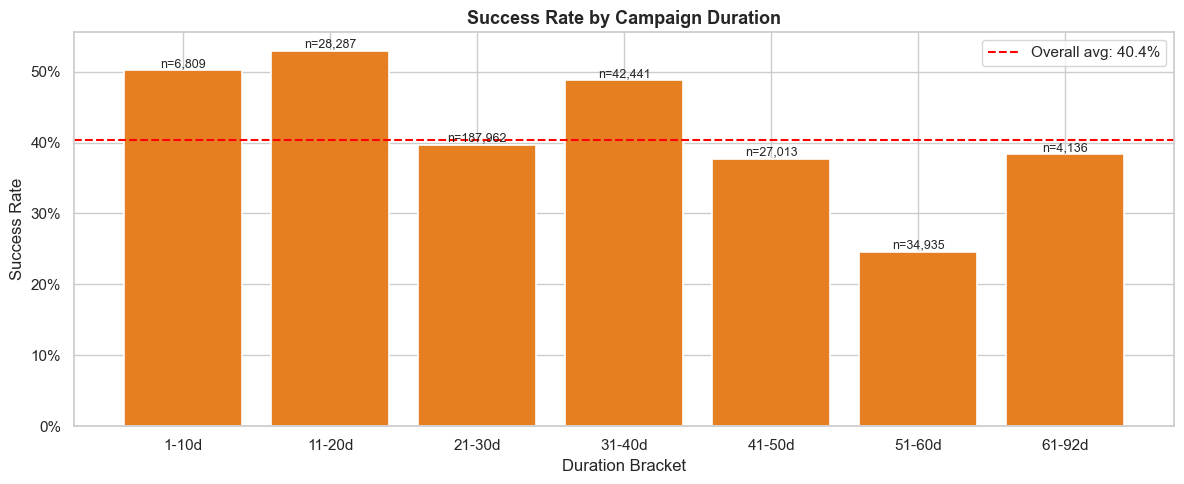

  ✅ Plot saved: plots/08_success_by_duration.png


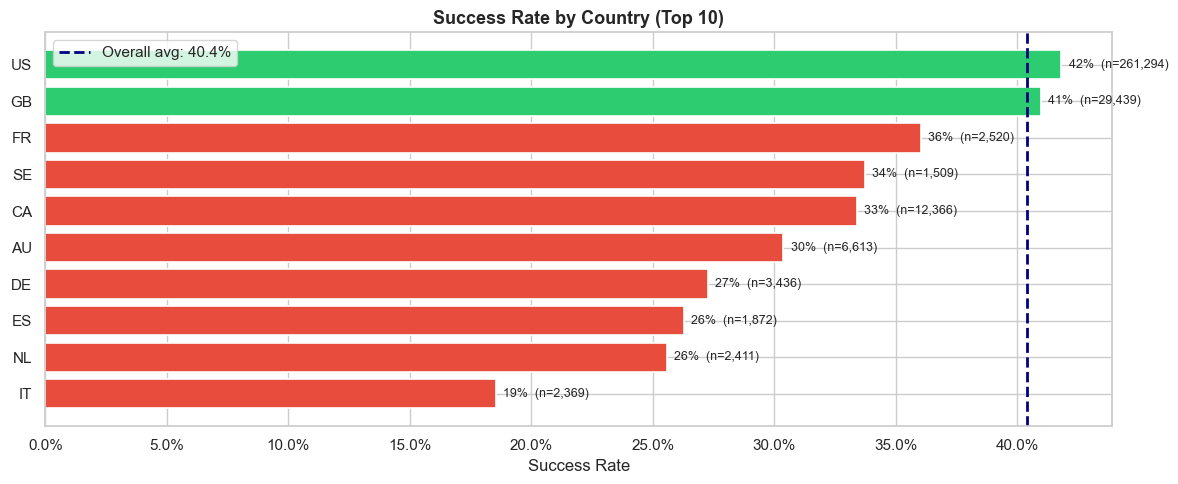

  ✅ Plot saved: plots/09_success_by_country.png


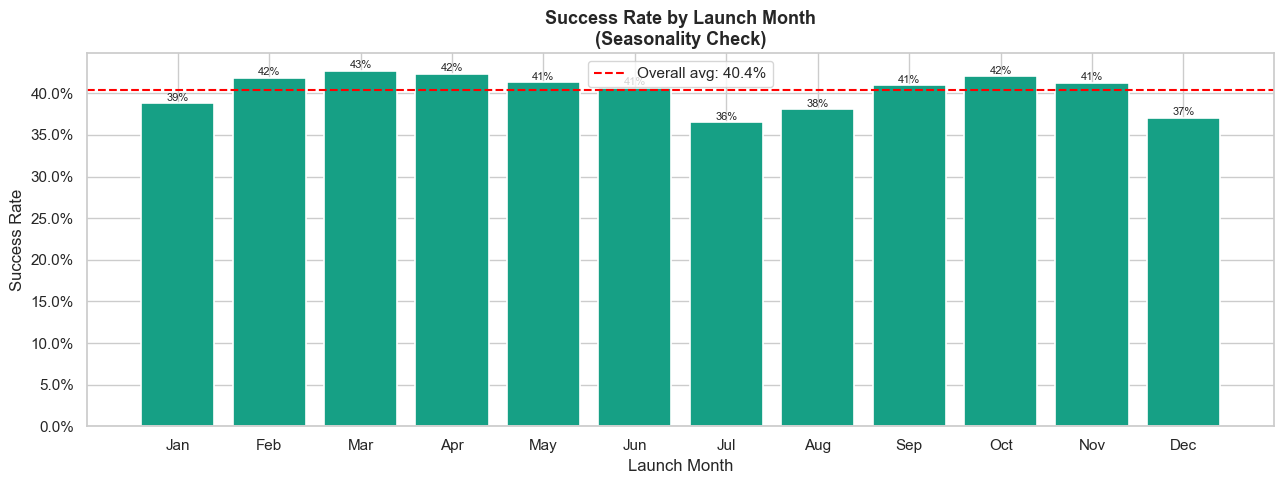

  ✅ Plot saved: plots/10_success_by_launch_month.png


In [ ]:

# ── Success rate by campaign duration bracket ─────────────────
dur_bins   = [0, 10, 20, 30, 40, 50, 60, 92]
dur_labels = ['1-10d', '11-20d', '21-30d', '31-40d',
              '41-50d', '51-60d', '61-92d']
df['dur_bin']   = pd.cut(df['campaign_duration_days'],
                         bins=dur_bins, labels=dur_labels)
succ_by_dur     = df.groupby('dur_bin', observed=True)['target'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(range(len(succ_by_dur)), succ_by_dur['mean'].values,
       color='#e67e22', edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(dur_labels)))
ax.set_xticklabels(dur_labels)
ax.set_title('Success Rate by Campaign Duration',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Duration Bracket')
ax.set_ylabel('Success Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(df['target'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Overall avg: {df['target'].mean():.1%}")
ax.legend()
for i, (rate, count) in enumerate(zip(succ_by_dur['mean'],
                                       succ_by_dur['count'])):
    ax.text(i, rate + 0.005, f'n={count:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/08_success_by_duration.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['dur_bin'], inplace=True)
print("  ✅ Plot saved: plots/08_success_by_duration.png")

# ── Success rate by top 10 countries ─────────────────────────
top10_countries = df['country'].value_counts().head(10).index
df_top10        = df[df['country'].isin(top10_countries)]
ctry_stats      = (df_top10.groupby('country')['target']
                            .agg(['mean', 'count'])
                            .sort_values('mean', ascending=True))

fig, ax = plt.subplots(figsize=(12, 5))
colors_c = ['#2ecc71' if r > df['target'].mean() else '#e74c3c'
            for r in ctry_stats['mean']]
ax.barh(ctry_stats.index, ctry_stats['mean'],
        color=colors_c, edgecolor='white', linewidth=1.2)
ax.axvline(df['target'].mean(), color='navy', linestyle='--', linewidth=2,
           label=f"Overall avg: {df['target'].mean():.1%}")
ax.set_title('Success Rate by Country (Top 10)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Success Rate')
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend()
for i, (rate, count) in enumerate(zip(ctry_stats['mean'],
                                       ctry_stats['count'])):
    ax.text(rate + 0.003, i, f'{rate:.0%}  (n={count:,})',
            va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plots/09_success_by_country.png', dpi=150, bbox_inches='tight')
plt.show()
print("  ✅ Plot saved: plots/09_success_by_country.png")

# ── Success rate by launch month ──────────────────────────────
df['launch_month_temp'] = df['launched'].dt.month
month_names             = ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec']
succ_by_month           = df.groupby('launch_month_temp')['target'].agg(['mean','count'])

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(range(len(succ_by_month)), succ_by_month['mean'].values,
       color='#16a085', edgecolor='white', linewidth=1.2)
ax.set_xticks(range(12))
ax.set_xticklabels(month_names)
ax.set_title('Success Rate by Launch Month\n(Seasonality Check)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Launch Month')
ax.set_ylabel('Success Rate')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.axhline(df['target'].mean(), color='red', linestyle='--', linewidth=1.5,
           label=f"Overall avg: {df['target'].mean():.1%}")
ax.legend()
for i, (rate, count) in enumerate(zip(succ_by_month['mean'],
                                       succ_by_month['count'])):
    ax.text(i, rate + 0.003, f'{rate:.0%}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('plots/10_success_by_launch_month.png', dpi=150, bbox_inches='tight')
plt.show()
df.drop(columns=['launch_month_temp'], inplace=True)
print("  ✅ Plot saved: plots/10_success_by_launch_month.png")

# ── END OF SECTION 10 ─────────────────────────────────────────

---
## Section 11 — Final Clean Dataset Summary

**What:** Compile the full record of every cleaning decision made, verify the final dataset, and confirm it is ready for the feature engineering + model pipeline.  
**Why:** Proof of work. Before model building, we need to confirm that (1) no leakage columns remain, (2) all dates are valid, (3) all durations are realistic, (4) the target is binary, and (5) there are no nulls in any feature column we intend to use.

**What to look for:** All checks should pass (✅). Any ❌ means something was missed.


In [ ]:
# ── STEP 1: Engineer date features FIRST ─────────────────────
# Why: These must exist before the checklist tries to verify them.
# launched carries useful time signals — extract as integers now
# so notebook 3 can use them without re-parsing dates.
df['launch_month']       = df['launched'].dt.month       # 1–12 seasonality
df['launch_day_of_week'] = df['launched'].dt.dayofweek   # 0=Mon 6=Sun
df['launch_year']        = df['launched'].dt.year        # platform growth trend

print("  ✅ Engineered: launch_month, launch_day_of_week, launch_year")

# ── STEP 2: Drop redundant columns ───────────────────────────
# goal  → mixed currencies, replaced by usd_goal_real
# state → string version of target, maximum leakage risk if left in
df.drop(columns=['goal', 'state'], inplace=True)
print("  ✅ Dropped: goal  (replaced by usd_goal_real)")
print("  ✅ Dropped: state (replaced by binary target column)")

# ── STEP 3: Final audit checklist ────────────────────────────
feature_cols = (CONFIG['numerical_cols'] +
                CONFIG['categorical_cols'] +
                [CONFIG['text_col']])

print("\n" + "=" * 60)
print("  FINAL DATASET AUDIT CHECKLIST")
print("=" * 60)

# Check 1: Shape
print(f"\n  ✅ Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Check 2: No leakage columns
leak_remaining = [c for c in CONFIG['leakage_cols'] if c in df.columns]
if len(leak_remaining) == 0:
    print("  ✅ No leakage columns present")
else:
    print(f"  ❌ Leakage columns still present: {leak_remaining}")

# Check 3: Target is binary
target_vals = df['target'].unique()
if set(target_vals) == {0, 1}:
    print("  ✅ Target is binary (0/1)")
else:
    print(f"  ❌ Target has unexpected values: {target_vals}")

# Check 4: No nulls in feature columns
null_check  = df[feature_cols].isnull().sum()
total_nulls = null_check.sum()
if total_nulls == 0:
    print("  ✅ Zero nulls in all feature columns")
else:
    print(f"  ❌ Nulls found:")
    print(null_check[null_check > 0])

# Check 5: Date validity
bad_dates = (df['launched'].dt.year < CONFIG['min_launch_year']).sum()
if bad_dates == 0:
    print(f"  ✅ All launch dates ≥ {CONFIG['min_launch_year']}")
else:
    print(f"  ❌ {bad_dates} corrupt dates remain")

# Check 6: Duration validity
bad_dur = (~df['campaign_duration_days'].between(
    CONFIG['min_duration_days'], CONFIG['max_duration_days'])).sum()
if bad_dur == 0:
    print(f"  ✅ All durations {CONFIG['min_duration_days']}–{CONFIG['max_duration_days']} days")
else:
    print(f"  ❌ {bad_dur} duration outliers remain")

# Check 7: Class balance
sr = df['target'].mean()
print(f"  ✅ Class balance: {sr:.1%} successful / {1-sr:.1%} failed")

# Check 8: New engineered columns present
new_cols     = ['launch_month', 'launch_day_of_week', 'launch_year']
missing_new  = [c for c in new_cols if c not in df.columns]
if not missing_new:
    print("  ✅ Date features engineered: launch_month, launch_day_of_week, launch_year")
else:
    print(f"  ❌ Missing date features: {missing_new}")

# Check 9: goal and state dropped
leaked_still = [c for c in ['goal', 'state'] if c in df.columns]
if not leaked_still:
    print("  ✅ Redundant columns dropped: goal, state")
else:
    print(f"  ❌ These should be dropped: {leaked_still}")

print()
print("=" * 60)
print("  CLEANING SUMMARY LOG")
print("=" * 60)
print(f"  Raw rows (2018 dataset)        : 378,661")
print(f"  After non-binary state filter  : 331,675  (canceled/live/etc removed)")
print(f"  After corrupt date filter      : 0 rows removed (dataset was clean)")
print(f"  After duration outlier filter  : 92 rows removed (0-day campaigns)")
print(f"  Final rows                     : {df.shape[0]:,}")
print(f"  Leakage columns removed        : {len(CONFIG['leakage_cols'])}")
print(f"  Redundant columns dropped      : goal, state")
print(f"  Features engineered            : campaign_duration_days, name_length,")
print(f"                                   launch_month, launch_day_of_week,")
print(f"                                   launch_year, target")

# ── STEP 4: Save once ─────────────────────────────────────────
os.makedirs('data', exist_ok=True)
df.to_csv('data/kickstarter_clean.csv', index=False)
print(f"\n  ✅ Saved → data/kickstarter_clean.csv")
print(f"     Shape   : {df.shape}")
print(f"     Columns : {df.columns.tolist()}")

  ✅ Engineered: launch_month, launch_day_of_week, launch_year
  ✅ Dropped: goal  (replaced by usd_goal_real)
  ✅ Dropped: state (replaced by binary target column)

  FINAL DATASET AUDIT CHECKLIST

  ✅ Final shape: 331,583 rows × 14 columns
  ✅ No leakage columns present
  ✅ Target is binary (0/1)
  ✅ Zero nulls in all feature columns
  ✅ All launch dates ≥ 2009
  ✅ All durations 1–92 days
  ✅ Class balance: 40.4% successful / 59.6% failed
  ✅ Date features engineered: launch_month, launch_day_of_week, launch_year
  ✅ Redundant columns dropped: goal, state

  CLEANING SUMMARY LOG
  Raw rows (2018 dataset)        : 378,661
  After non-binary state filter  : 331,675  (canceled/live/etc removed)
  After corrupt date filter      : 0 rows removed (dataset was clean)
  After duration outlier filter  : 92 rows removed (0-day campaigns)
  Final rows                     : 331,583
  Leakage columns removed        : 5
  Redundant columns dropped      : goal, state
  Features engineered            

---
## Section 12 — What Comes Next

This notebook is complete. Here is what the next notebooks will build on top of this clean foundation:

| Notebook | What it does |
|---|---|
| `02_text_pipeline.ipynb` | TF-IDF vectorization of campaign `name` → sparse `[N × 2500]` matrix |
| `03_tabular_pipeline.ipynb` | StandardScaler + OneHotEncoder via ColumnTransformer → dense tabular matrix |
| `04_fusion.ipynb` | `scipy.sparse.hstack` combining text and tabular matrices |
| `05_model_training.ipynb` | LogisticRegression with StratifiedKFold, PR-AUC evaluation |
| `06_evaluation.ipynb` | Feature coefficients, PR curves, threshold tuning |
| `07_inference.ipynb` | `predict_campaign(input_dict)` — the product |

The clean dataset at `data/kickstarter_clean.csv` is the input to all subsequent notebooks.  
**Rule for all next notebooks:** Load from `data/kickstarter_clean.csv`. Never rerun this audit notebook as a dependency — the cleaning is done once, documented here, and the output is saved.
